<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/TemporalDifferenceLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

# number of states
n_states = 5

# value function initialized to 0
V = np.zeros(n_states)

# parameters
alpha = 0.1      # learning rate
gamma = 0.9      # discount factor

# simple environment: move right until terminal state
def step(state):
    if state == n_states - 1:
        return state, 0  # terminal state

    next_state = state + 1
    reward = 1 if next_state == n_states - 1 else 0

    return next_state, reward


# run episodes
for episode in range(100):

    state = 0  # start state

    while state != n_states - 1:

        next_state, reward = step(state)

        # TD(0) update (IMPORTANT LINE)
        V[state] += alpha * (reward + gamma * V[next_state] - V[state])

        state = next_state

print("State Values:", V)

State Values: [0.7232872  0.80842464 0.89971048 0.99997344 0.        ]


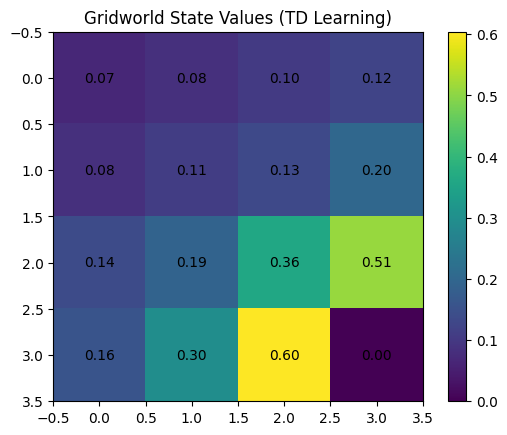

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Grid size
n = 4

# Value function (initialize all states to 0)
V = np.zeros((n, n))

# Parameters
alpha = 0.1
gamma = 0.9

# Terminal state
goal = (n-1, n-1)

# Possible actions: up, down, left, right
actions = [(-1,0), (1,0), (0,-1), (0,1)]

def step(state):
    """
    Take random action and return next state + reward
    """
    if state == goal:
        return state, 0

    action = actions[np.random.randint(len(actions))]
    next_state = (state[0] + action[0], state[1] + action[1])

    # stay inside grid
    next_state = (
        max(0, min(n-1, next_state[0])),
        max(0, min(n-1, next_state[1]))
    )

    # reward only at goal
    reward = 1 if next_state == goal else 0

    return next_state, reward


# Training using TD(0)
episodes = 5000

for ep in range(episodes):
    state = (0, 0)  # start from top-left

    while state != goal:
        next_state, reward = step(state)

        # TD Update
        s = state
        ns = next_state

        V[s] += alpha * (reward + gamma * V[ns] - V[s])

        state = next_state


# =========================
# Visualization
# =========================
plt.figure()
plt.imshow(V)

# Show values inside grid
for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{V[i,j]:.2f}", ha='center', va='center')

plt.title("Gridworld State Values (TD Learning)")
plt.colorbar()
plt.show()